In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using {device}')

Using cuda


In [3]:
print("FlashAttention available:", torch.backends.cuda.flash_sdp_enabled())

FlashAttention available: True


In [4]:
data = pd.read_csv('data.csv').to_numpy()
data = (data - data.mean(axis=1).reshape(-1, 1)) / data.std(axis=1).reshape(-1, 1)

In [5]:
train_length = round(len(data) * 0.8)

train_data = torch.tensor(data[:train_length], dtype=torch.float32)
test_data = torch.tensor(data[train_length:], dtype=torch.float32)
all_data = torch.tensor(data, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(train_data), batch_size=16, shuffle=True)
test_loader = DataLoader(TensorDataset(test_data), batch_size=16, shuffle=False)
all_loader = DataLoader(TensorDataset(all_data), batch_size=16, shuffle=True)

In [6]:
class TransformerAE(nn.Module):
    def __init__(self, input_dim, seq_length, d_model, nhead=4, num_layers=1, bottleneck_dim=48):
        super(TransformerAE, self).__init__()
        
        self.seq_length = seq_length
        self.d_model = d_model
        
        self.input_proj = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.bottleneck = nn.Linear(seq_length * d_model, bottleneck_dim)
        self.bottleneck_decoder = nn.Linear(bottleneck_dim, seq_length * d_model)
        
        decoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.decoder = nn.TransformerEncoder(decoder_layer, num_layers=num_layers)
        
        self.output_proj = nn.Linear(d_model, input_dim)
        
    def encode(self, x):
        x = self.input_proj(x)
        x = self.encoder(x)
        x = x.flatten(start_dim=1)
        x = self.bottleneck(x)
        return x
    
    def decode(self, x):
        x = self.bottleneck_decoder(x)
        x = x.unflatten(1, (self.seq_length, self.d_model))
        x = self.decoder(x)
        x = self.output_proj(x)
        return x
    
    def forward(self, x):
        x = self.encode(x)
        x = self.decode(x)
        return x
        

In [7]:
model = TransformerAE(input_dim=48, d_model=48, seq_length=31).to(device)

In [8]:
k = 0
for param in model.parameters():
    if param.requires_grad:
        k += torch.prod(torch.tensor(param.size()))
print(f'Model has {k} trainable parameters')

Model has 565696 trainable parameters


In [9]:
optimizer = optim.AdamW(model.parameters(), lr=3e-4)
criterion = nn.MSELoss()

In [10]:
all_train_losses = []
train_losses = []
test_losses = []

In [11]:
epochs = 25

for epoch in range(epochs):
    avg_loss = 0
    model.train()
    for batch in train_loader:
        
        batch = batch[0].unsqueeze(1).view(-1, 31, 48).to(device)
        preds = model(batch)
        loss = criterion(preds, batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        all_train_losses.append(loss.item())
        avg_loss += loss.item()
    avg_loss /= len(train_loader)
    print(f'Epoch {epoch + 1}, Loss: {avg_loss:.4f}')
    train_losses.append(avg_loss)
    
    model.eval()
    avg_test_loss = 0
    with torch.no_grad():
        for batch in test_loader:
            batch = batch[0].unsqueeze(1).view(-1, 31, 48).to(device)
            preds = model(batch)
            loss = criterion(preds, batch)
            
            avg_test_loss += loss.item()
    avg_test_loss /= len(test_loader)
    test_losses.append(avg_test_loss)
    print(f'Test Loss: {avg_test_loss:.4f}')

C:\ProgramData\anaconda3\envs\nir\lib\site-packages\torch\nn\functional.py:5504: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:455.)
  attn_output = scaled_dot_product_attention(q, k, v, attn_mask, dropout_p, is_causal)


Epoch 1, Loss: 0.6352
Test Loss: 0.4925
Epoch 2, Loss: 0.4863
Test Loss: 0.4514
Epoch 3, Loss: 0.4475
Test Loss: 0.4191
Epoch 4, Loss: 0.4121
Test Loss: 0.3903
Epoch 5, Loss: 0.3876
Test Loss: 0.3730
Epoch 6, Loss: 0.3719
Test Loss: 0.3610
Epoch 7, Loss: 0.3609
Test Loss: 0.3529
Epoch 8, Loss: 0.3539
Test Loss: 0.3540
Epoch 9, Loss: 0.3476
Test Loss: 0.3438
Epoch 10, Loss: 0.3425
Test Loss: 0.3405
Epoch 11, Loss: 0.3389
Test Loss: 0.3382
Epoch 12, Loss: 0.3353
Test Loss: 0.3350
Epoch 13, Loss: 0.3312
Test Loss: 0.3333
Epoch 14, Loss: 0.3277
Test Loss: 0.3318
Epoch 15, Loss: 0.3254
Test Loss: 0.3301
Epoch 16, Loss: 0.3247
Test Loss: 0.3304
Epoch 17, Loss: 0.3222
Test Loss: 0.3299
Epoch 18, Loss: 0.3202
Test Loss: 0.3278
Epoch 19, Loss: 0.3178
Test Loss: 0.3278
Epoch 20, Loss: 0.3175
Test Loss: 0.3262
Epoch 21, Loss: 0.3150
Test Loss: 0.3263
Epoch 22, Loss: 0.3137
Test Loss: 0.3266
Epoch 23, Loss: 0.3118
Test Loss: 0.3288
Epoch 24, Loss: 0.3099
Test Loss: 0.3259
Epoch 25, Loss: 0.3088
Te

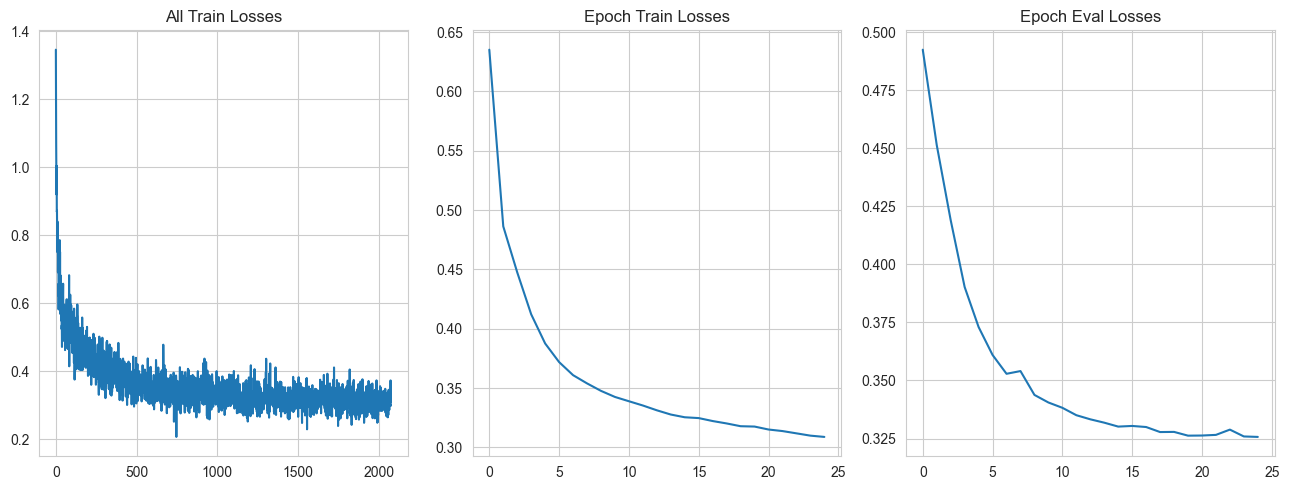

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
axes[0].plot(all_train_losses)
axes[0].set_title('All Train Losses')
axes[1].plot(train_losses)
axes[1].set_title('Epoch Train Losses')
axes[2].plot(test_losses)
axes[2].set_title('Epoch Eval Losses')
plt.tight_layout()
plt.show()

In [13]:
model = TransformerAE(input_dim=48, d_model=48, seq_length=31).to(device)

optimizer = optim.AdamW(model.parameters(), lr=3e-4)
criterion = nn.MSELoss()

In [14]:
epochs = 25

for epoch in range(epochs):
    avg_loss = 0
    model.train()
    for batch in all_loader:
        
        batch = batch[0].unsqueeze(1).view(-1, 31, 48).to(device)
        preds = model(batch)
        loss = criterion(preds, batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        avg_loss += loss.item()
    avg_loss /= len(train_loader)
    print(f'Epoch {epoch + 1}, Loss: {avg_loss:.4f}')

Epoch 1, Loss: 0.7699
Epoch 2, Loss: 0.5853
Epoch 3, Loss: 0.5263
Epoch 4, Loss: 0.4853
Epoch 5, Loss: 0.4622
Epoch 6, Loss: 0.4463
Epoch 7, Loss: 0.4347
Epoch 8, Loss: 0.4264
Epoch 9, Loss: 0.4212
Epoch 10, Loss: 0.4158
Epoch 11, Loss: 0.4112
Epoch 12, Loss: 0.4075
Epoch 13, Loss: 0.4032
Epoch 14, Loss: 0.4000
Epoch 15, Loss: 0.3976
Epoch 16, Loss: 0.3949
Epoch 17, Loss: 0.3926
Epoch 18, Loss: 0.3906
Epoch 19, Loss: 0.3883
Epoch 20, Loss: 0.3868
Epoch 21, Loss: 0.3851
Epoch 22, Loss: 0.3831
Epoch 23, Loss: 0.3810
Epoch 24, Loss: 0.3799
Epoch 25, Loss: 0.3780


In [48]:
# torch.save(model.state_dict(), 'models/TAE.pt')

In [15]:
errors = []
encoded = []
reconstructed = []
with torch.no_grad():
    for sample in all_data:
        inputs = sample.view(-1, 31, 48).to(device)
        res = model(inputs).cpu().detach().flatten()
        reconstruction_error = criterion(res, sample)
        errors.append(reconstruction_error.cpu().detach().numpy())
        
        features = model.encode(inputs).view(-1)
        encoded.append(features.cpu().detach().numpy())
        
        reconstructed.append(res.view(-1).cpu().detach().numpy())
errors = np.array(errors)
encoded = np.array(encoded)
reconstructed = np.array(reconstructed)

In [17]:
def plot_sample(sample):
    _, ax = plt.subplots(figsize=(20, 5))
    ax.plot(data[sample], label='True')
    pred_row = reconstructed[sample]
    ax.plot(pred_row, label='Predicted')
    mse = np.linalg.norm(data[sample] - pred_row) ** 2 / len(data[sample])
    ax.set_title(f'Model Prediction VS True Series, MSE: {mse.round(2)}, Sample: {sample}')
    plt.legend()
    plt.show()

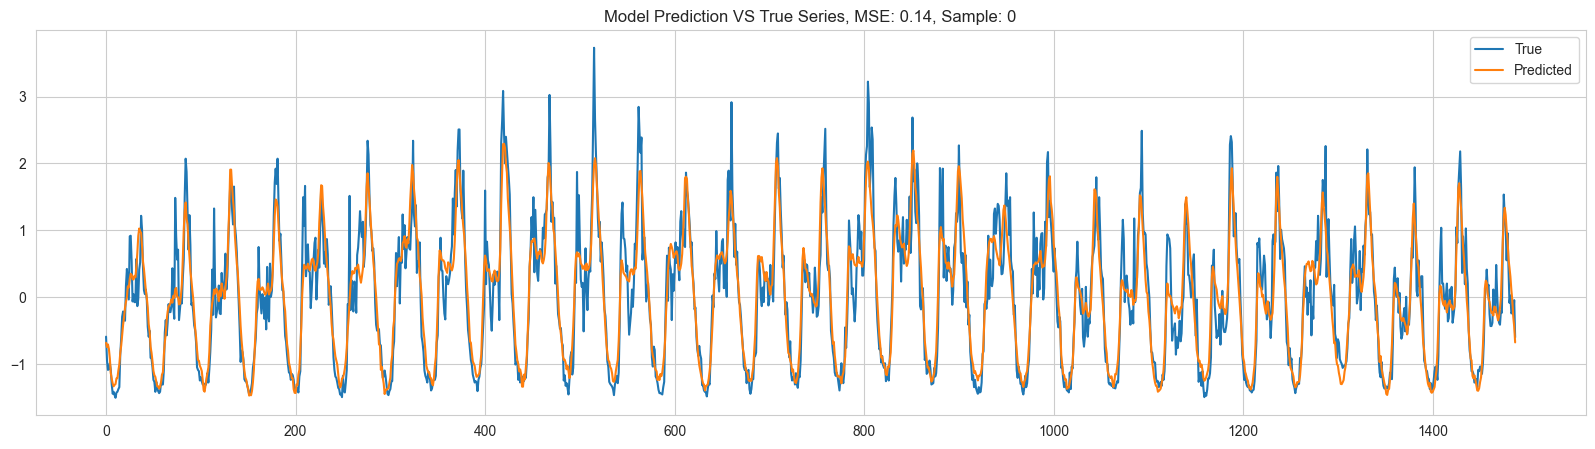

In [18]:
plot_sample(0)

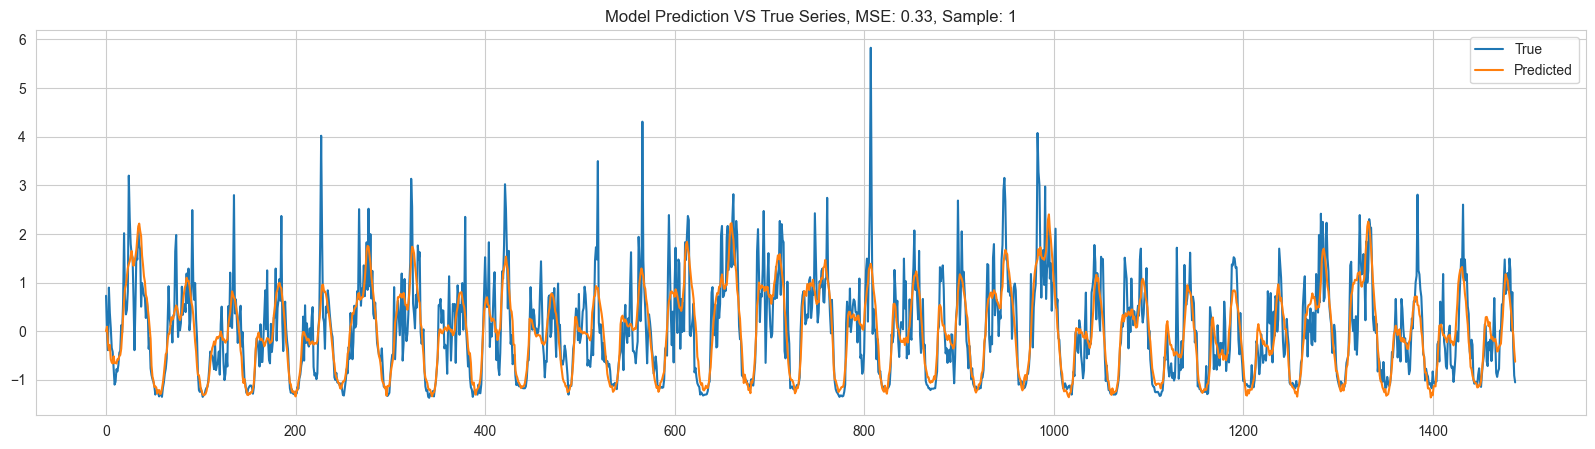

In [19]:
plot_sample(1)

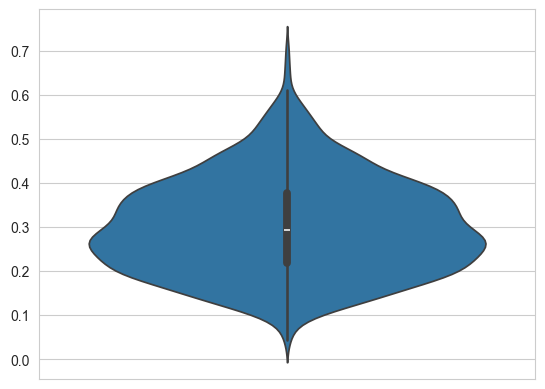

In [20]:
sns.violinplot(errors)
plt.show()

In [21]:
np.quantile(errors, 0.99)

0.5769711273908615

In [22]:
np.column_stack((np.argsort(-errors), -np.sort(-errors)))

array([[9.08000000e+02, 7.05488980e-01],
       [1.22500000e+03, 6.98234499e-01],
       [2.80000000e+01, 6.67857170e-01],
       ...,
       [1.10200000e+03, 5.98902255e-02],
       [6.54000000e+02, 4.68684509e-02],
       [2.23000000e+02, 4.34879586e-02]])

In [ ]:
# 908.0,0.705489
# 1225.0,0.698234
# 28.0,0.667857
# 1578.0,0.657484
# 142.0,0.646461
# 554.0,0.635281
# 446.0,0.618733
# 170.0,0.609607
# 1178.0,0.597694
# 1354.0,0.589254

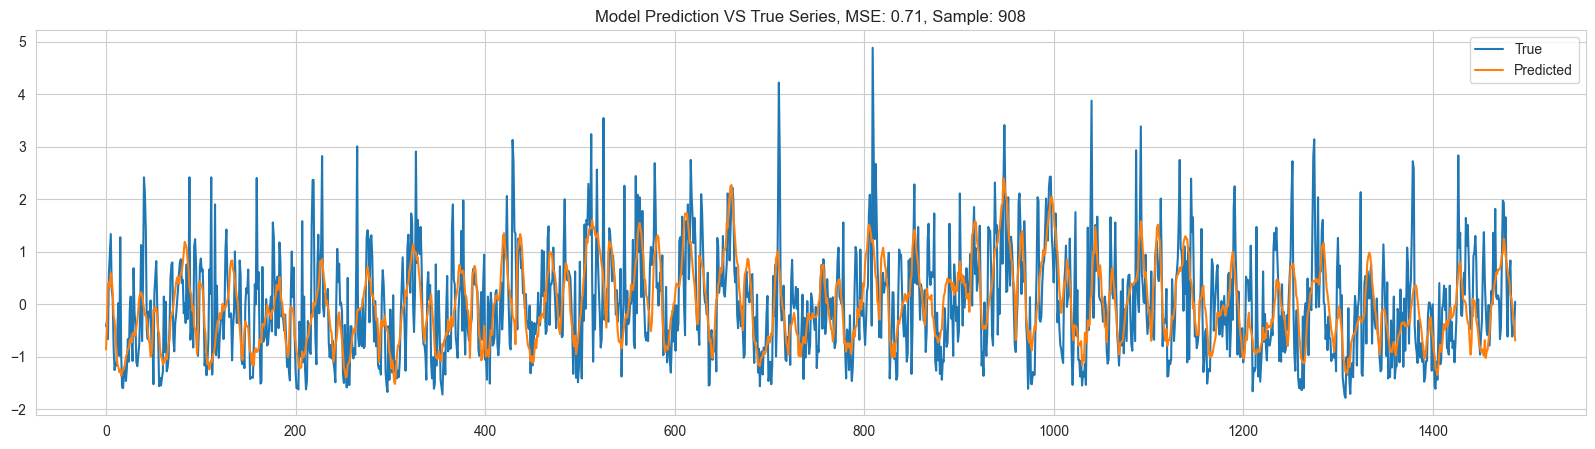

In [23]:
plot_sample(908)

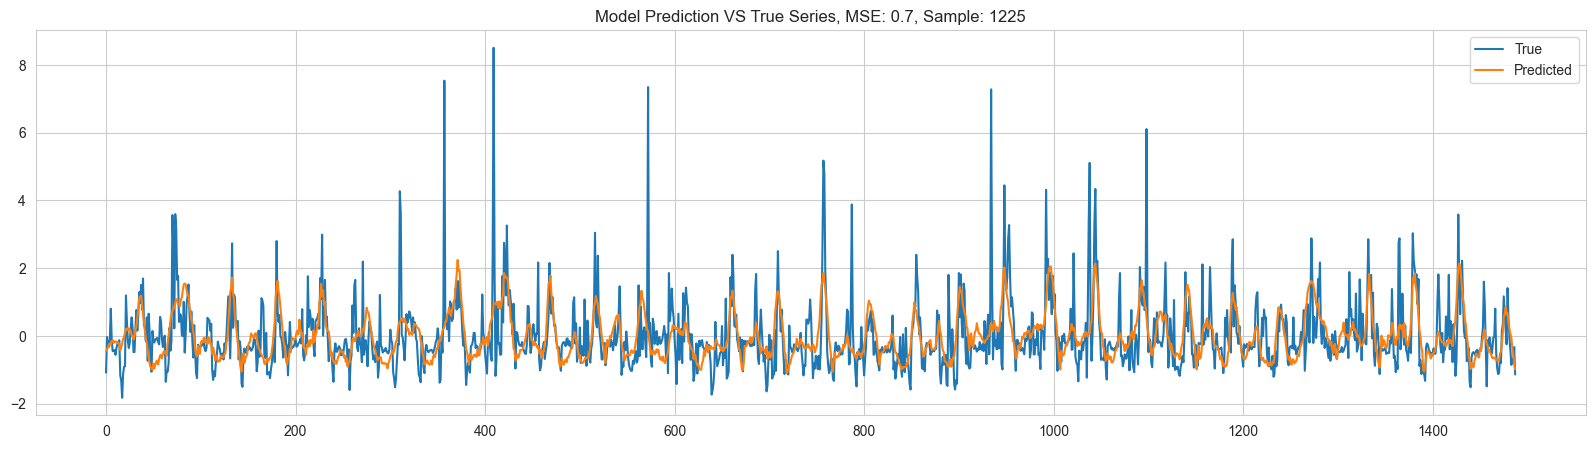

In [24]:
plot_sample(1225)

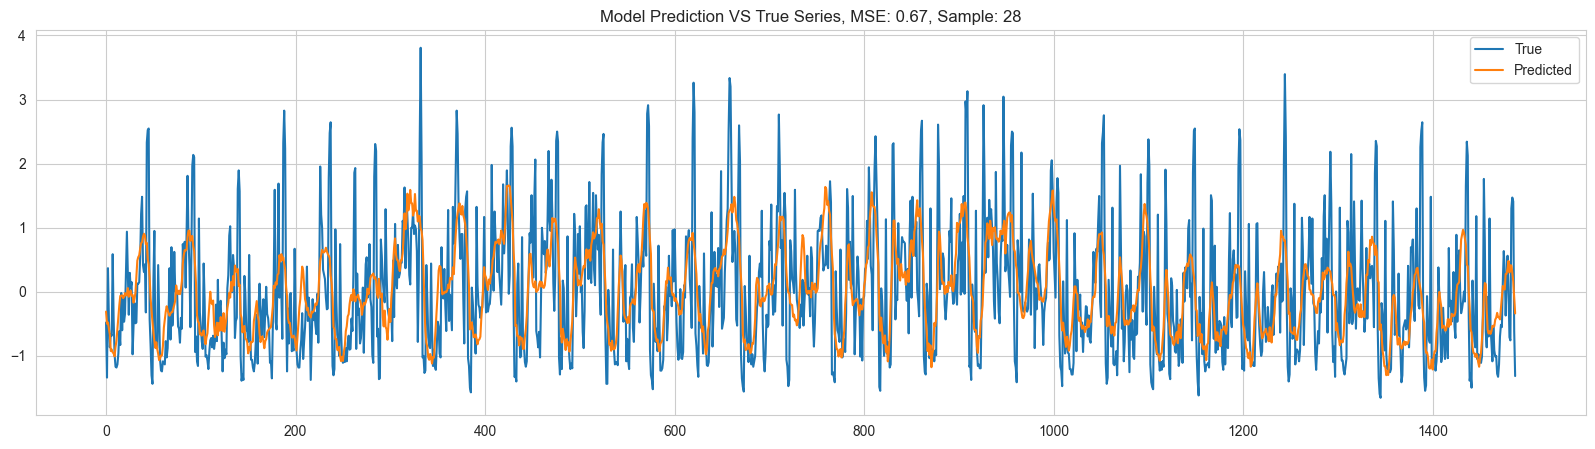

In [25]:
plot_sample(28)

In [89]:
# torch.save(model.state_dict(), './models/transformer_ae.pt')

In [26]:
encoded_norm = (encoded - encoded.mean(axis=0)) / encoded.std(axis=0)

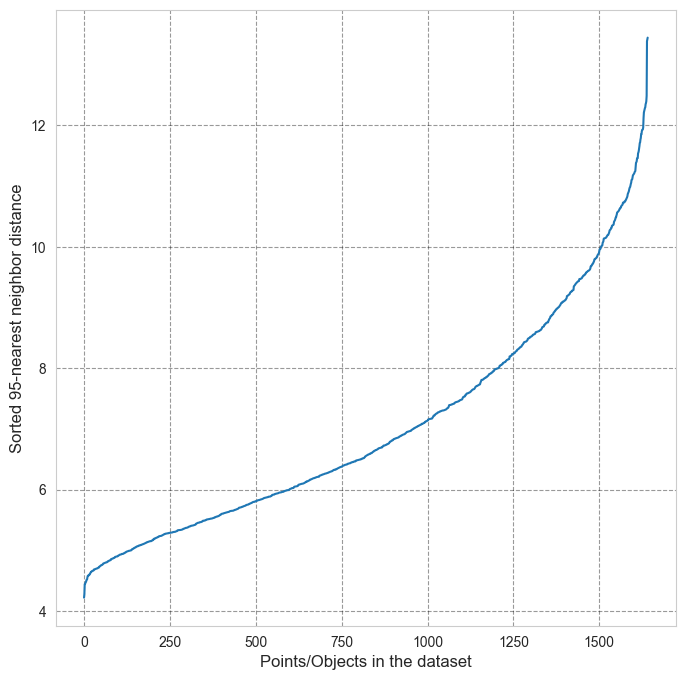

In [27]:
from sklearn.neighbors import NearestNeighbors


def get_kdist_plot(X=None, k=None, radius_nbrs=1.0):

    nbrs = NearestNeighbors(n_neighbors=k, radius=radius_nbrs).fit(X)

    # For each point, compute distances to its k-nearest neighbors
    distances, indices = nbrs.kneighbors(X) 
                                       
    distances = np.sort(distances, axis=0)
    distances = distances[:, k-1]

    # Plot the sorted K-nearest neighbor distance for each point in the dataset
    plt.figure(figsize=(8,8))
    plt.plot(distances)
    plt.xlabel('Points/Objects in the dataset', fontsize=12)
    plt.ylabel('Sorted {}-nearest neighbor distance'.format(k), fontsize=12)
    plt.grid(True, linestyle="--", color='black', alpha=0.4)
    plt.show()
    plt.close()


k = 2 * encoded_norm.shape[-1] - 1 # k=2*{dim(dataset)} - 1
get_kdist_plot(X=encoded_norm, k=k)

In [37]:
from sklearn.cluster import DBSCAN

# Создаем объект DBSCAN
dbscan = DBSCAN(eps=9.9, min_samples=15)

# Проводим кластеризацию данных
clusters = dbscan.fit_predict(encoded_norm)

# Ищем объекты, отнесенные к кластеру -1 (это аномалии)
anomalies_indices = np.where(clusters == -1)[0]
anomalies_indices

array([  56,  122,  394,  528,  647,  704, 1034, 1167, 1168, 1416],
      dtype=int64)

In [ ]:
#  56,  122,  394,  528,  647,  704, 1034, 1167, 1168, 1416
# 122, 1168, 1416

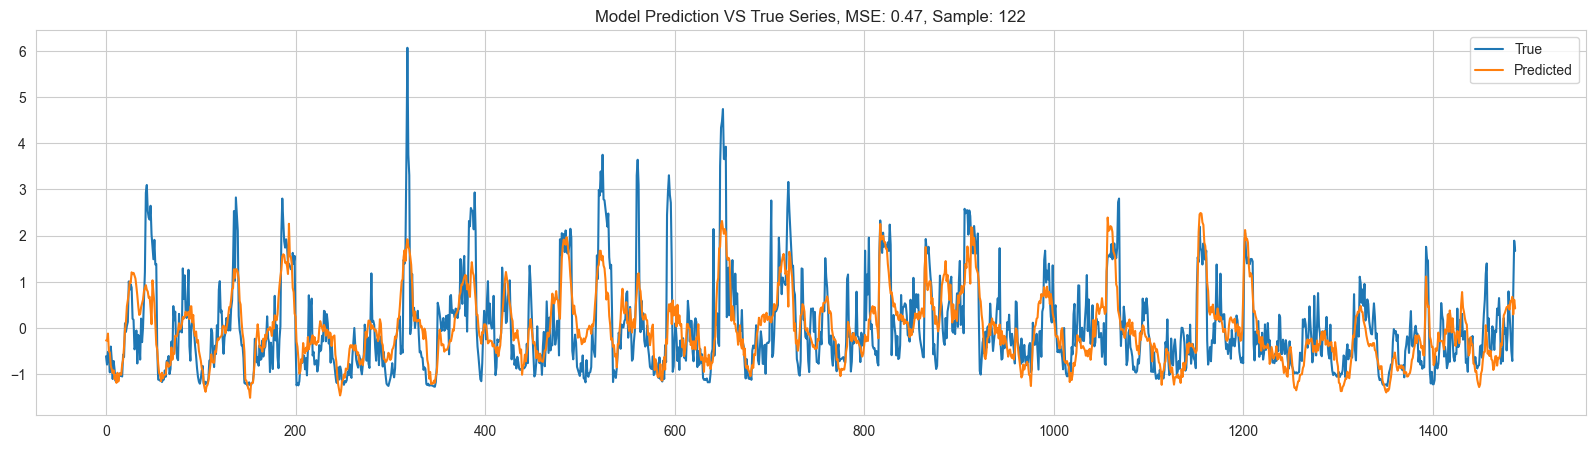

In [38]:
plot_sample(122)

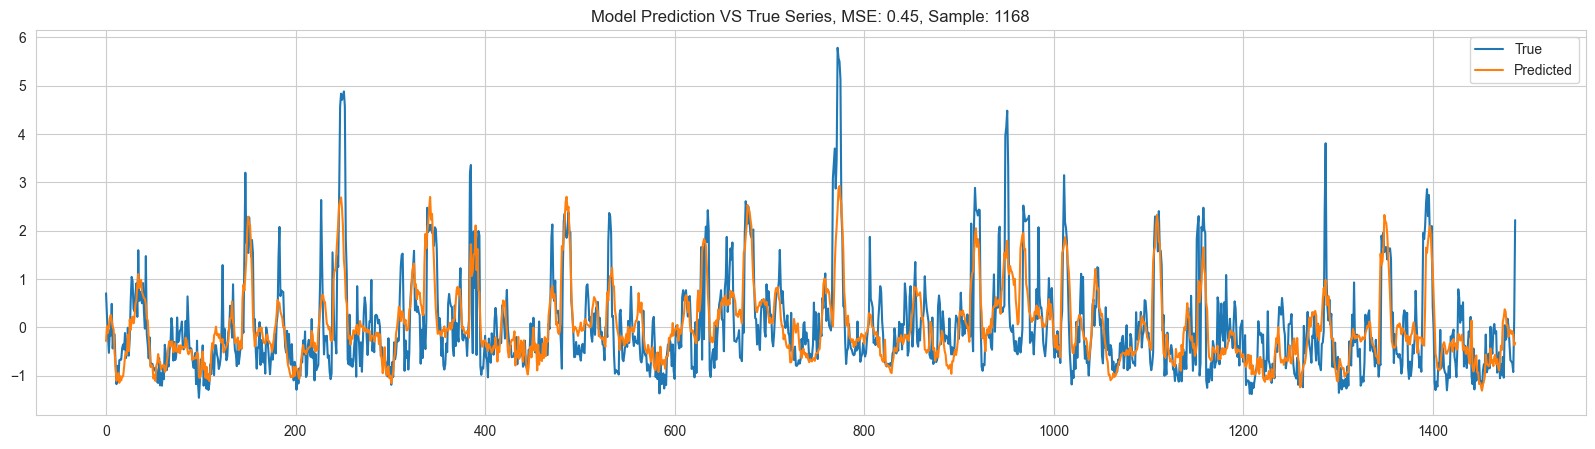

In [39]:
plot_sample(1168)

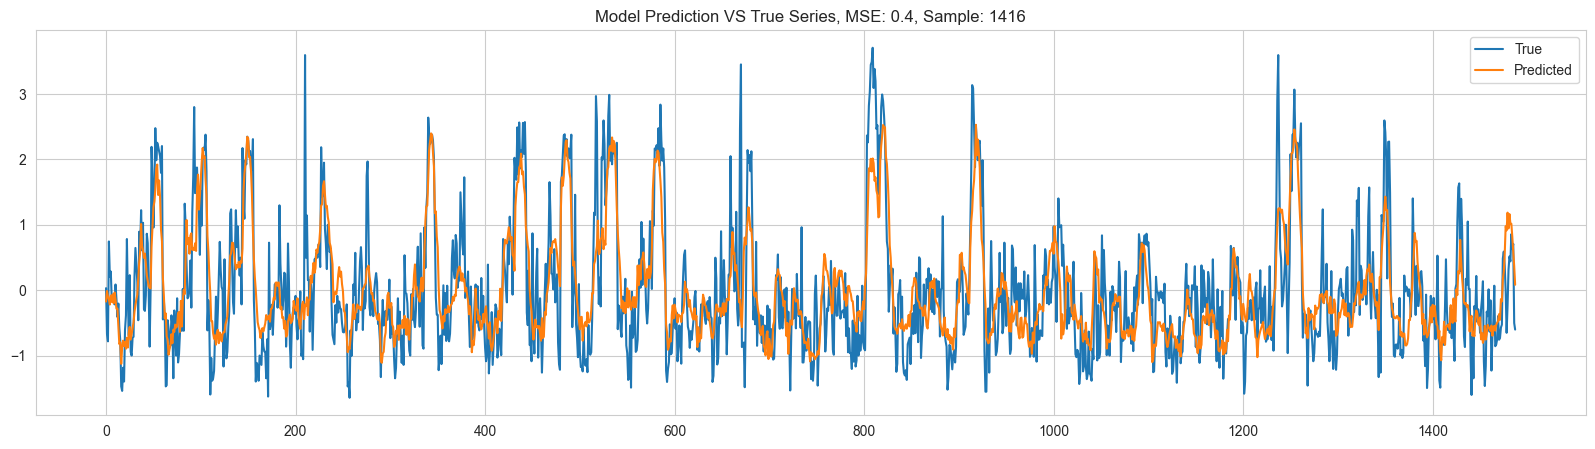

In [40]:
plot_sample(1416)

In [41]:
medians = np.median(encoded_norm, axis=0)
middle = np.repeat(np.inf, 4)
cur_min = np.inf
for sample in encoded_norm:
    dist = np.dot(sample - medians, sample - medians)
    if dist < cur_min:
        cur_min = dist
        middle = sample
q = 0.001
dists = np.linalg.norm(encoded_norm - middle, axis=1)
band = max(np.quantile(dists, q), 1e-3)
band

3.394867788553238

In [42]:
from sklearn.neighbors import KernelDensity

kde = KernelDensity(kernel='gaussian', bandwidth=band)
kde.fit(encoded_norm)
kde_scores = kde.score_samples(encoded_norm)
min_max = 1 - (kde_scores - kde_scores.min()) / (kde_scores.max() - kde_scores.min())

<Axes: >

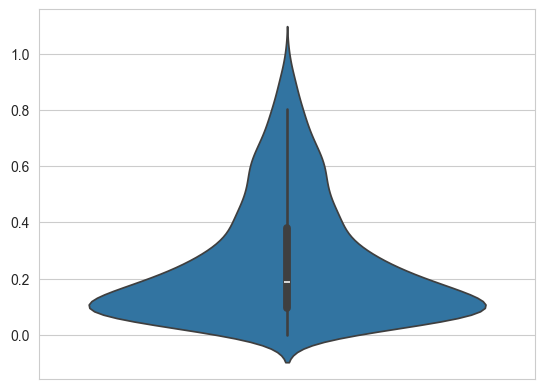

In [43]:
sns.violinplot(min_max)

In [44]:
np.vstack((-np.sort(-min_max), np.argsort(-min_max))).T

array([[1.00000000e+00, 6.47000000e+02],
       [9.94447798e-01, 6.03000000e+02],
       [9.92181399e-01, 1.06600000e+03],
       ...,
       [1.64434522e-03, 2.63000000e+02],
       [3.23996119e-04, 2.25000000e+02],
       [0.00000000e+00, 1.50500000e+03]])

In [ ]:
# 1.000000,647.0
# 0.994448,603.0
# 0.992181,1066.0
# 0.950765,1018.0
# 0.948162,1443.0
# 0.932670,1168.0
# 0.931165,1167.0
# 0.927857,693.0
# 0.921093,720.0
# 0.920148,969.0

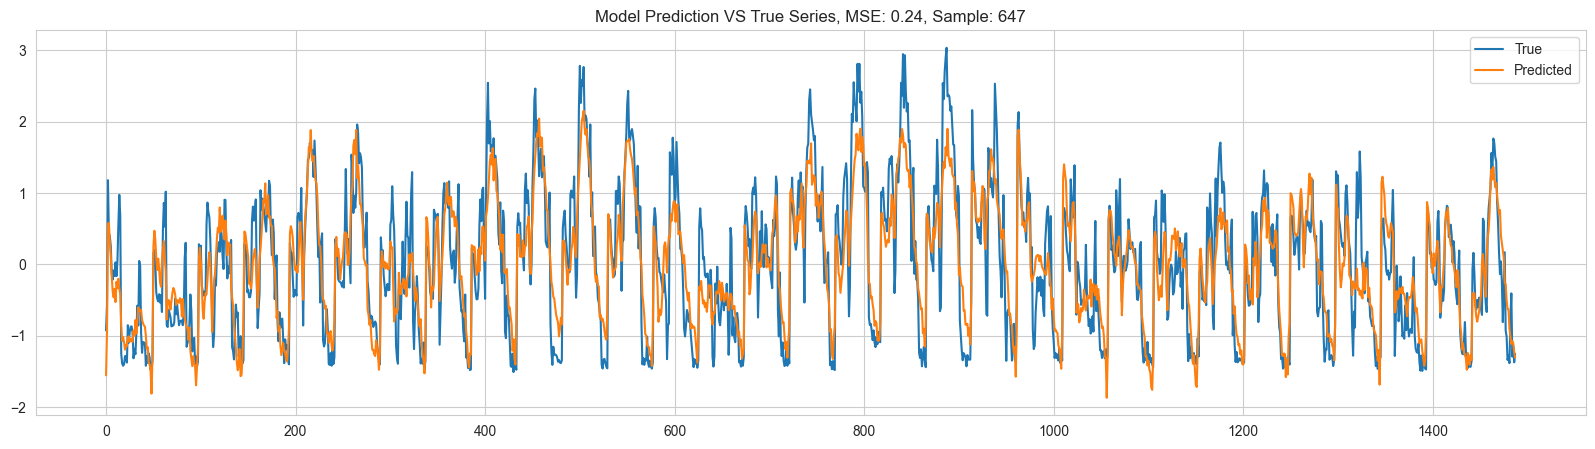

In [45]:
plot_sample(647)

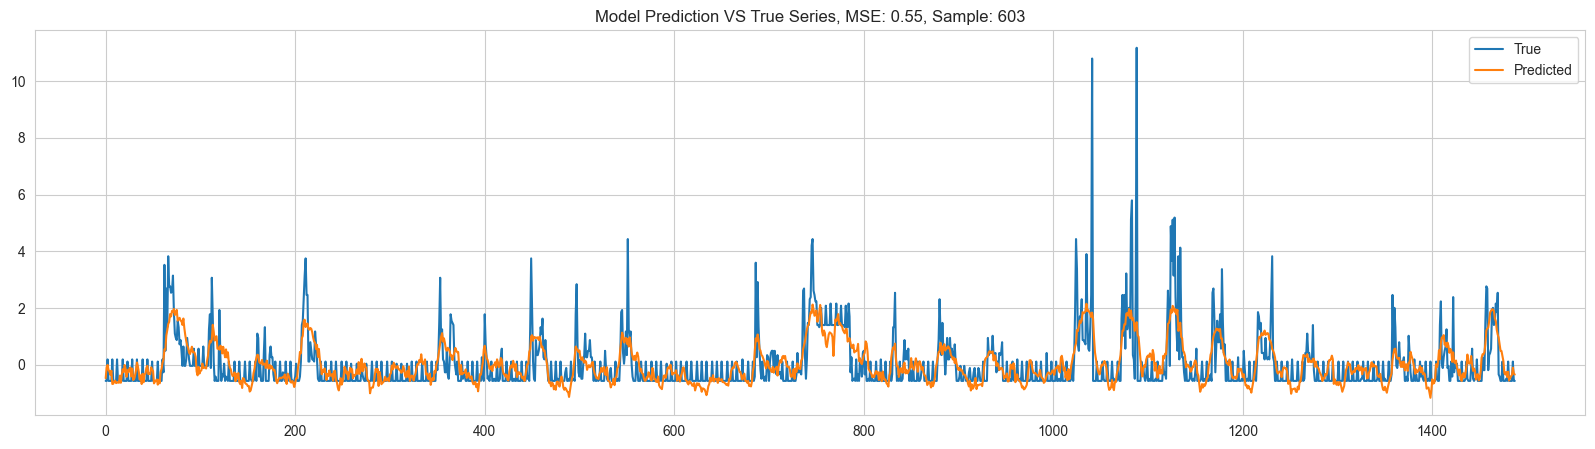

In [46]:
plot_sample(603)

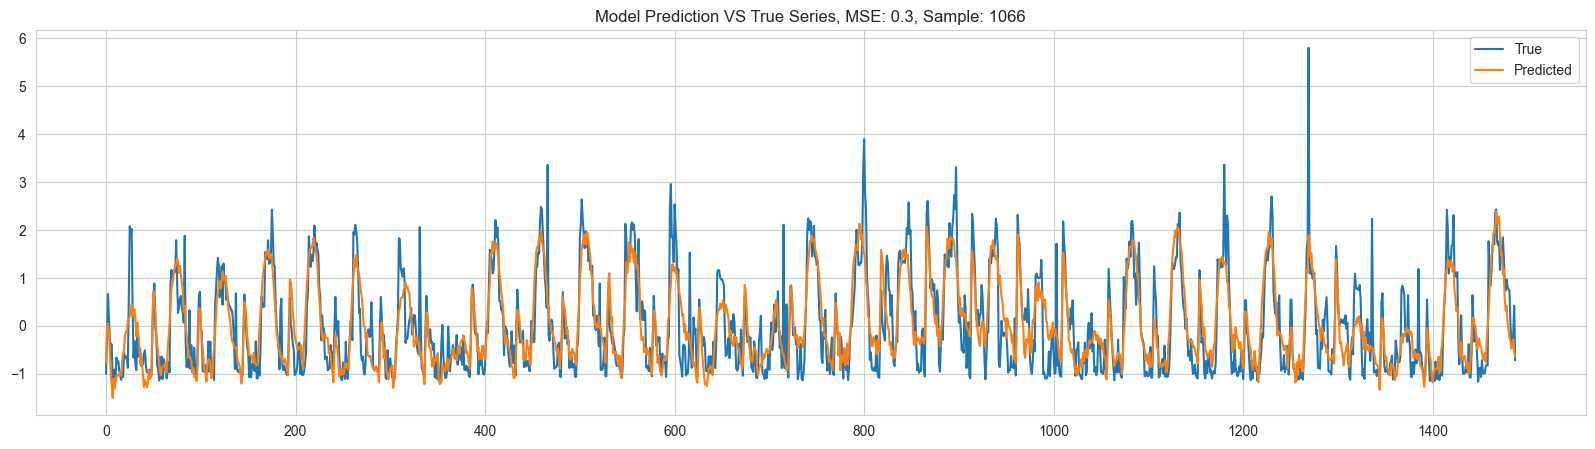

In [47]:
plot_sample(1066)